In [1]:
# ============================================================
# CELL 1 — SETUP
# ============================================================

!pip -q install datasets

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from google.colab import drive

drive.mount('/content/drive')
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.11.0+cu128
CUDA available: True
Device: cuda


In [2]:
import os

SAVE_DIR = "/content/drive/MyDrive/DeepGlobe_Project"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Saving models to:", SAVE_DIR)

Saving models to: /content/drive/MyDrive/DeepGlobe_Project


In [3]:
# ============================================================
# CELL 2 — LOAD DATASET
# ============================================================

DATASET_NAME = "ratnaonline1/deepglobe-land-cover-classification-dataset"

print("Loading DeepGlobe dataset...")

dataset = load_dataset(DATASET_NAME)

print(dataset)
print()
print("Number of training samples:", len(dataset["train"]))
print("Columns:", dataset["train"].column_names)

Loading DeepGlobe dataset...


README.md:   0%|          | 0.00/361 [00:00<?, ?B/s]

data/train-00000-of-00005.parquet: reconstructing file:   0%|          |  0.00B /  418MB            

data/train-00000-of-00005.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00005.parquet: reconstructing file:   0%|          |  0.00B /  415MB            

...

data/train-00003-of-00005.parquet: downloading bytes:           |  0.00B            

data/train-00004-of-00005.parquet: reconstructing file:   0%|          |  0.00B /  409MB            

data/train-00004-of-00005.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/803 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'mask'],
        num_rows: 803
    })
})

Number of training samples: 803
Columns: ['pixel_values', 'mask']


In [4]:
# ============================================================
# CELL 3 — INSPECT RAW DATA
# ============================================================

sample = dataset["train"][0]

image = sample["pixel_values"]
mask = sample["mask"]

print("Image type:", type(image))
print("Mask type:", type(mask))

print("Image size:", image.size)
print("Mask size:", mask.size)

image_np = np.array(image)
mask_np = np.array(mask)

print()
print("Image shape:", image_np.shape)
print("Image dtype:", image_np.dtype)

print("Mask shape:", mask_np.shape)
print("Mask dtype:", mask_np.dtype)

if mask_np.ndim == 3:
    unique_colors = np.unique(
        mask_np.reshape(-1, 3),
        axis=0
    )

    print()
    print("Number of unique RGB colors:", len(unique_colors))
    print("First colors:")
    print(unique_colors[:20])

else:
    print()
    print("Unique mask values:", np.unique(mask_np))

Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Mask type: <class 'PIL.PngImagePlugin.PngImageFile'>
Image size: (2448, 2448)
Mask size: (2448, 2448)

Image shape: (2448, 2448, 3)
Image dtype: uint8
Mask shape: (2448, 2448)
Mask dtype: uint8

Unique mask values: [1 2]


In [5]:
# ============================================================
# CELL 4 — DEEPGLOBE MASK CONVERSION
# ============================================================

NUM_CLASSES = 7

CLASS_NAMES = [
    "Urban",
    "Agriculture",
    "Rangeland",
    "Forest",
    "Water",
    "Barren",
    "Unknown"
]

# RGB -> class ID
RGB_TO_CLASS = {
    (0, 255, 255): 0,   # Urban
    (255, 255, 0): 1,   # Agriculture
    (255, 0, 255): 2,   # Rangeland
    (0, 255, 0): 3,     # Forest
    (0, 0, 255): 4,     # Water
    (255, 255, 255): 5, # Barren
    (0, 0, 0): 6        # Unknown
}


def rgb_mask_to_class(mask):
    """
    Convert DeepGlobe RGB mask into integer class IDs.
    """

    arr = np.array(mask)

    # If already single-channel
    if arr.ndim == 2:
        return arr.astype(np.int64)

    # RGB mask
    if arr.ndim == 3 and arr.shape[2] == 3:

        class_mask = np.full(
            arr.shape[:2],
            fill_value=6,
            dtype=np.int64
        )

        for rgb, class_id in RGB_TO_CLASS.items():

            matches = np.all(arr == np.array(rgb), axis=2)

            class_mask[matches] = class_id

        return class_mask

    raise ValueError(
        f"Unexpected mask shape: {arr.shape}"
    )

In [6]:
# ============================================================
# CELL 5 — VERIFY MASK CONVERSION
# ============================================================

converted_mask = rgb_mask_to_class(mask)

print("Converted mask shape:", converted_mask.shape)
print("Converted mask dtype:", converted_mask.dtype)

unique_classes, counts = np.unique(
    converted_mask,
    return_counts=True
)

print()
print("Classes found:")

for cls, count in zip(unique_classes, counts):

    percentage = 100 * count / converted_mask.size

    print(
        f"{cls}: {CLASS_NAMES[cls]:12s} "
        f"{count:,} pixels "
        f"({percentage:.2f}%)"
    )

Converted mask shape: (2448, 2448)
Converted mask dtype: int64

Classes found:
1: Agriculture  5,818,441 pixels (97.09%)
2: Rangeland    174,263 pixels (2.91%)


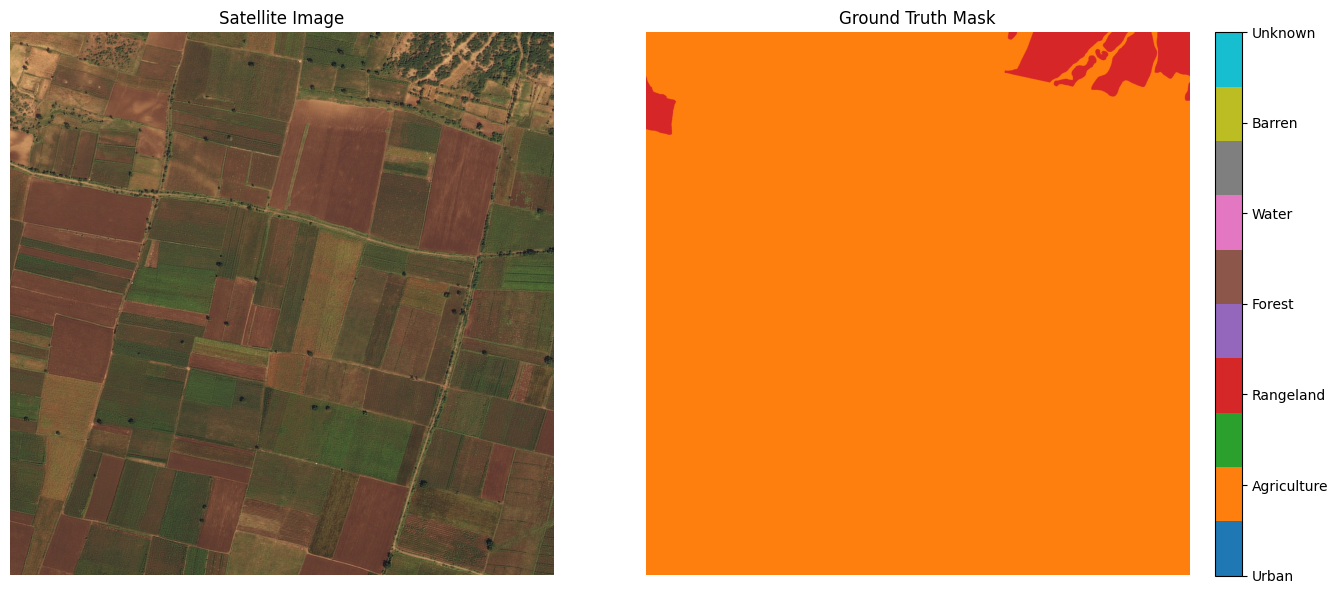

In [7]:
# ============================================================
# CELL 6 — VISUALIZE SAMPLE
# ============================================================

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

plt.imshow(image)
plt.title("Satellite Image")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    converted_mask,
    cmap="tab10",
    vmin=0,
    vmax=NUM_CLASSES - 1
)

plt.title("Ground Truth Mask")
plt.axis("off")

cbar = plt.colorbar(
    ticks=np.arange(NUM_CLASSES),
    fraction=0.046,
    pad=0.04
)

cbar.ax.set_yticklabels(CLASS_NAMES)

plt.tight_layout()
plt.show()

In [8]:
class DeepGlobeDataset(torch.utils.data.Dataset):

    def __init__(self, hf_dataset, indices, transform=None):
        self.dataset = hf_dataset
        self.indices = [int(i) for i in indices]   # IMPORTANT
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Convert BOTH indices to normal Python int
        idx = int(idx)
        real_idx = int(self.indices[idx])

        item = self.dataset[real_idx]

        image = item["pixel_values"]
        mask = item["mask"]

        # PIL conversion
        if not isinstance(image, Image.Image):
            image = Image.fromarray(np.array(image))

        if not isinstance(mask, Image.Image):
            mask = Image.fromarray(np.array(mask))

        # Resize
        image = image.resize((256, 256), Image.BILINEAR)
        mask = mask.resize((256, 256), Image.NEAREST)

        # Convert image
        image = np.array(image).astype(np.float32) / 255.0
        image = torch.from_numpy(image).permute(2, 0, 1)

        # Convert mask
        mask = np.array(mask).astype(np.int64)
        mask = torch.from_numpy(mask)

        return image, mask

In [9]:
from sklearn.model_selection import train_test_split

hf_train = dataset["train"]

indices = np.arange(len(hf_train))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_dataset = DeepGlobeDataset(
    hf_train,
    train_indices
)

val_dataset = DeepGlobeDataset(
    hf_train,
    val_indices
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 642
Validation samples: 161


In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 81
Validation batches: 21


In [11]:
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks:", masks.shape)
print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)
print("Mask classes:", torch.unique(masks))

Images: torch.Size([8, 3, 256, 256])
Masks: torch.Size([8, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.int64
Mask classes: tensor([0, 1, 2, 3, 4, 5, 6])


In [12]:
# ============================================================
# CELL: Small U-Net
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class SmallUNet(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # Output
        self.output = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(self.pool(e1))

        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.output(d1)


# Create model
model = SmallUNet(num_classes=7).to(device)

print(model)

SmallUNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_s

In [13]:
# ============================================================
# CELL: Model sanity check
# ============================================================

images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape: ", images.shape)
print("Target shape:", masks.shape)
print("Output shape:", outputs.shape)

assert outputs.shape == (images.shape[0], 7, 256, 256)

print("✓ U-Net forward pass successful")

Input shape:  torch.Size([8, 3, 256, 256])
Target shape: torch.Size([8, 256, 256])
Output shape: torch.Size([8, 7, 256, 256])
✓ U-Net forward pass successful


In [ ]:
# ============================================================
# CELL: Loss function and optimizer
# ============================================================

import torch.optim as optim

# Cross-entropy for multi-class semantic segmentation
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
# ============================================================
# CELL: Train U-Net
# ============================================================

num_epochs = 10

best_val_loss = float("inf")

train_losses = []
val_losses = []

best_model_path = "/content/best_small_unet.pth"

for epoch in range(num_epochs):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------
    model.train()

    running_train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, masks)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # --------------------------------------------------------
    # SAVE ONLY BEST MODEL
    # --------------------------------------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
         model.state_dict(),
            "/content/drive/MyDrive/DeepGlobe_Project/best_balanced_unet.pth"
               )

        saved = " ✓ Saved best model"

    else:
        saved = ""

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
        f"{saved}"
    )

print("\nTraining complete.")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best model saved to: {best_model_path}")

Epoch 1/10 | Train Loss: 1.3173 | Val Loss: 1.3075 ✓ Saved best model
Epoch 2/10 | Train Loss: 1.2851 | Val Loss: 1.2658 ✓ Saved best model
Epoch 3/10 | Train Loss: 1.2679 | Val Loss: 1.2877
Epoch 4/10 | Train Loss: 1.2389 | Val Loss: 1.2897
Epoch 5/10 | Train Loss: 1.1559 | Val Loss: 1.2654 ✓ Saved best model
Epoch 6/10 | Train Loss: 1.1392 | Val Loss: 1.2489 ✓ Saved best model
Epoch 7/10 | Train Loss: 1.1050 | Val Loss: 1.1467 ✓ Saved best model
Epoch 8/10 | Train Loss: 1.1107 | Val Loss: 1.1521
Epoch 9/10 | Train Loss: 1.0887 | Val Loss: 1.1055 ✓ Saved best model
Epoch 10/10 | Train Loss: 1.0717 | Val Loss: 1.1086

Training complete.
Best validation loss: 1.1055
Best model saved to: /content/best_small_unet.pth


In [ ]:
# ============================================================
# CELL: Load BEST model
# ============================================================

best_model = SmallUNet(num_classes=7).to(device)

best_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/DeepGlobe_Project/best_balanced_unet.pth",
        map_location=device
    )
)

best_model.eval()

print("✓ Best model loaded successfully")

✓ Best model loaded successfully


In [ ]:
# ============================================================
# CELL: Calculate IoU and Dice
# ============================================================

@torch.no_grad()
def evaluate_model(model, loader, num_classes=7):

    model.eval()

    total_intersection = np.zeros(num_classes)
    total_union = np.zeros(num_classes)

    total_pred = np.zeros(num_classes)
    total_target = np.zeros(num_classes)

    for images, masks in loader:

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1).cpu().numpy()
        masks = masks.numpy()

        for cls in range(num_classes):

            pred_cls = predictions == cls
            target_cls = masks == cls

            intersection = np.logical_and(
                pred_cls,
                target_cls
            ).sum()

            union = np.logical_or(
                pred_cls,
                target_cls
            ).sum()

            total_intersection[cls] += intersection
            total_union[cls] += union

            total_pred[cls] += pred_cls.sum()
            total_target[cls] += target_cls.sum()

    ious = []
    dices = []

    print("========================================")
    print("PER-CLASS RESULTS")
    print("========================================")

    for cls in range(num_classes):

        if total_union[cls] > 0:

            iou = (
                total_intersection[cls]
                / total_union[cls]
            )

            denominator = (
                total_pred[cls]
                + total_target[cls]
            )

            if denominator > 0:
                dice = (
                    2 * total_intersection[cls]
                    / denominator
                )
            else:
                dice = 0.0

            ious.append(iou)
            dices.append(dice)

            print(
                f"{cls}: "
                f"{CLASS_NAMES[cls]:12s} | "
                f"IoU = {iou:.4f} | "
                f"Dice = {dice:.4f}"
            )

        else:

            print(
                f"{cls}: "
                f"{CLASS_NAMES[cls]:12s} | "
                f"No pixels"
            )

    mean_iou = np.mean(ious)
    mean_dice = np.mean(dices)

    print("========================================")
    print(f"Mean IoU : {mean_iou:.4f}")
    print(f"Mean Dice: {mean_dice:.4f}")
    print("========================================")

    return mean_iou, mean_dice


mean_iou, mean_dice = evaluate_model(
    best_model,
    val_loader
)

PER-CLASS RESULTS
0: Urban        | IoU = 0.2446 | Dice = 0.3930
1: Agriculture  | IoU = 0.6300 | Dice = 0.7730
2: Rangeland    | IoU = 0.0000 | Dice = 0.0000
3: Forest       | IoU = 0.0934 | Dice = 0.1708
4: Water        | IoU = 0.1134 | Dice = 0.2036
5: Barren       | IoU = 0.0000 | Dice = 0.0000
6: Unknown      | IoU = 0.0000 | Dice = 0.0000
Mean IoU : 0.1545
Mean Dice: 0.2201


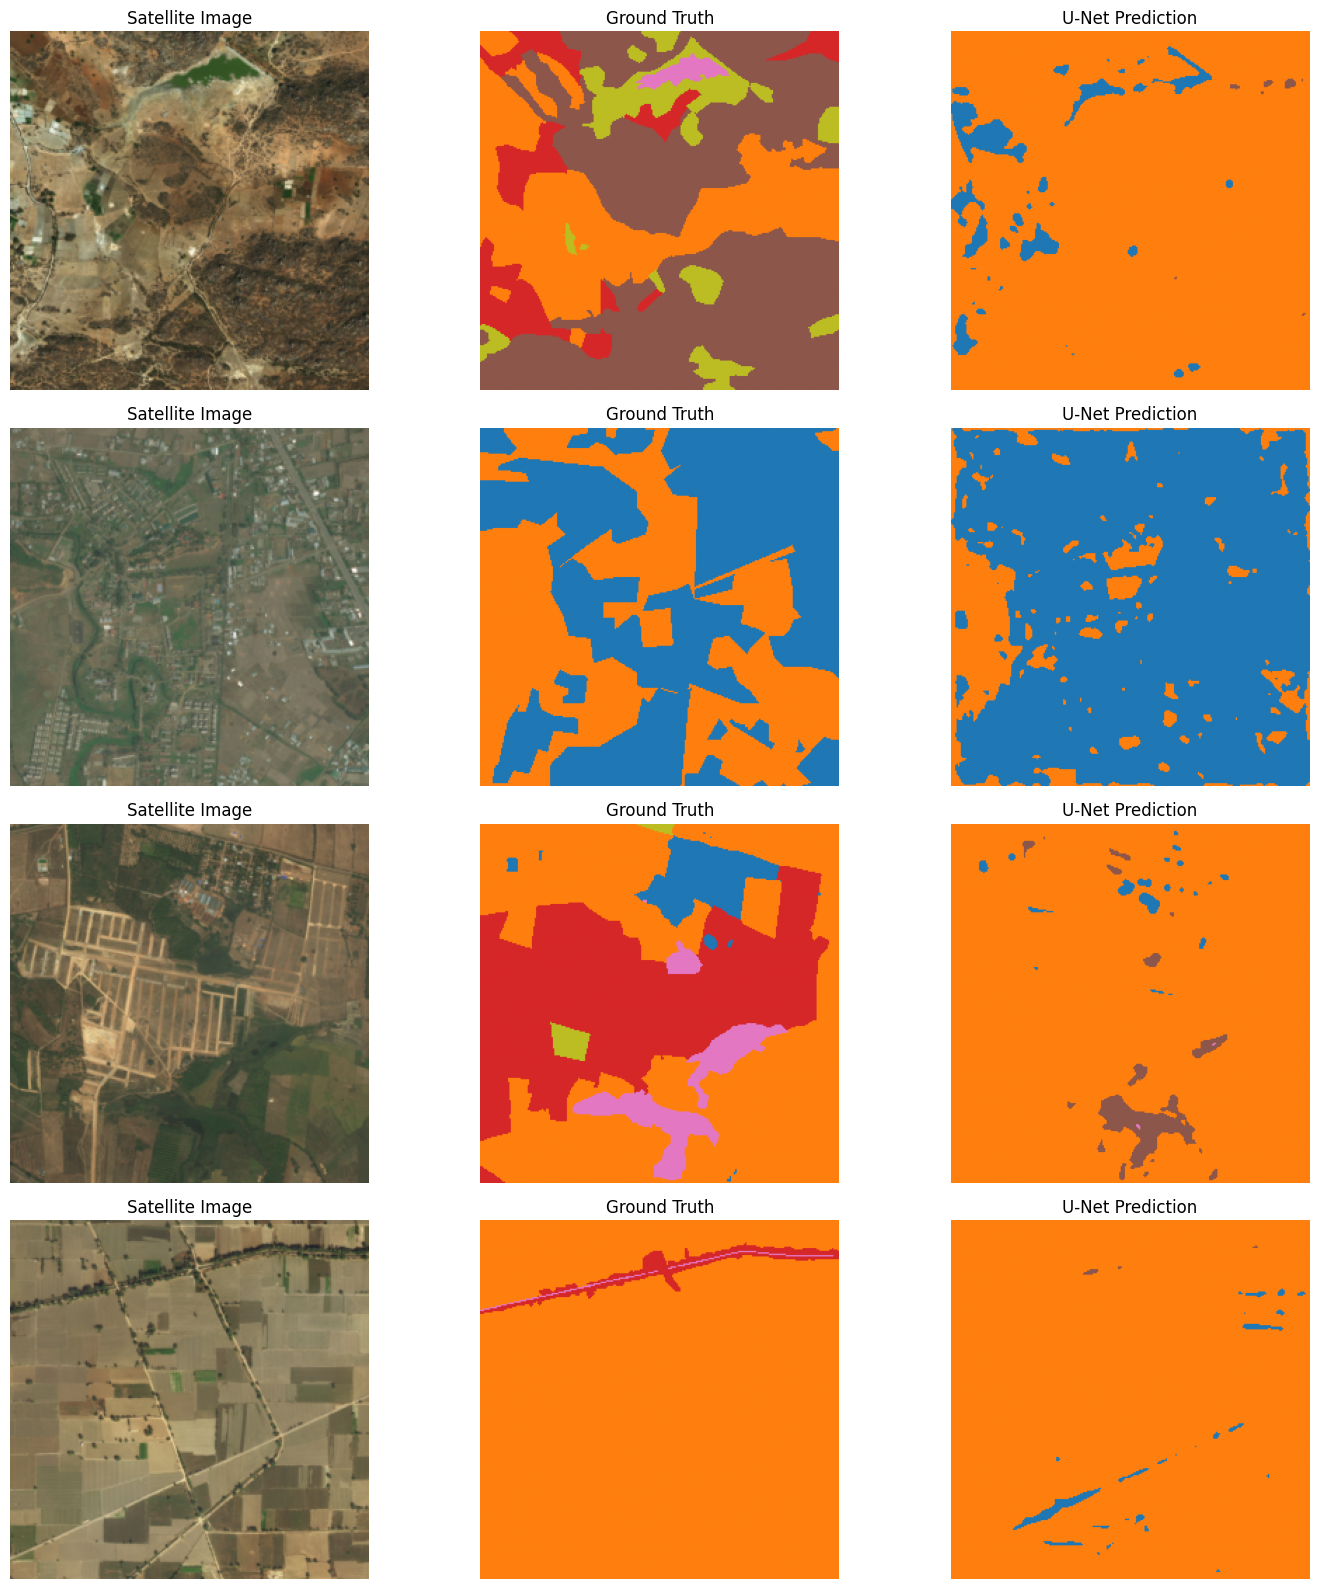

In [ ]:
# ============================================================
# CELL: Visualize predictions
# ============================================================

best_model.eval()

images, masks = next(iter(val_loader))

with torch.no_grad():

    outputs = best_model(
        images.to(device)
    )

predictions = outputs.argmax(
    dim=1
).cpu()

num_show = min(4, len(images))

plt.figure(figsize=(15, 4 * num_show))

for i in range(num_show):

    # Satellite image
    plt.subplot(num_show, 3, i * 3 + 1)

    img = images[i].permute(1, 2, 0).numpy()

    plt.imshow(img)
    plt.title("Satellite Image")
    plt.axis("off")

    # Ground truth
    plt.subplot(num_show, 3, i * 3 + 2)

    plt.imshow(
        masks[i],
        cmap="tab10",
        vmin=0,
        vmax=6
    )

    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(num_show, 3, i * 3 + 3)

    plt.imshow(
        predictions[i],
        cmap="tab10",
        vmin=0,
        vmax=6
    )

    plt.title("U-Net Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP: RETRAIN WITH CLASS-BALANCED CE + DICE LOSS
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm

print("=" * 60)
print("CLASS-BALANCED RETRAINING")
print("=" * 60)

# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------------
# 2. Load the BEST model from previous training
# ------------------------------------------------------------

best_model_path = "/content/drive/MyDrive/DeepGlobe_Project/best_balanced_unet.pth"

model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

model = model.to(device)

print("Loaded previous best model:")
print(best_model_path)

# ------------------------------------------------------------
# 3. Calculate class frequencies from training data
# ------------------------------------------------------------

NUM_CLASSES = 7

class_counts = torch.zeros(NUM_CLASSES, dtype=torch.float64)

print("\nCalculating class frequencies...")

with torch.no_grad():

    for images, masks in tqdm(train_loader):

        masks = masks.long()

        for c in range(NUM_CLASSES):
            class_counts[c] += (masks == c).sum().item()

print("\nPixel counts per class:")

class_names = [
    "Urban",
    "Agriculture",
    "Rangeland",
    "Forest",
    "Water",
    "Barren",
    "Unknown"
]

total_pixels = class_counts.sum()

for i in range(NUM_CLASSES):
    percentage = 100 * class_counts[i] / total_pixels

    print(
        f"{i}: {class_names[i]:12s} "
        f"{int(class_counts[i]):12,d} pixels "
        f"({percentage:.3f}%)"
    )

# ------------------------------------------------------------
# 4. Create balanced class weights
# ------------------------------------------------------------
#
# We use inverse square-root frequency rather than pure
# inverse frequency because pure inverse frequency can
# make the rarest classes overwhelmingly important.
#
# ------------------------------------------------------------

frequencies = class_counts / total_pixels

weights = 1.0 / torch.sqrt(frequencies + 1e-8)

# Normalize weights so their mean is approximately 1
weights = weights / weights.mean()

weights = weights.float().to(device)

print("\nClass weights:")

for i in range(NUM_CLASSES):
    print(
        f"{i}: {class_names[i]:12s} -> "
        f"{weights[i].item():.4f}"
    )

# ------------------------------------------------------------
# 5. Weighted Cross Entropy
# ------------------------------------------------------------

ce_loss = nn.CrossEntropyLoss(
    weight=weights
)

# ------------------------------------------------------------
# 6. Multiclass Dice Loss
# ------------------------------------------------------------

def multiclass_dice_loss(
    logits,
    targets,
    num_classes=7,
    weights=None
):

    probs = torch.softmax(logits, dim=1)

    targets_one_hot = F.one_hot(
        targets,
        num_classes=num_classes
    )

    targets_one_hot = targets_one_hot.permute(
        0, 3, 1, 2
    ).float()

    # Flatten spatial dimensions
    probs = probs.contiguous().view(
        probs.size(0),
        num_classes,
        -1
    )

    targets_one_hot = targets_one_hot.contiguous().view(
        targets_one_hot.size(0),
        num_classes,
        -1
    )

    intersection = (
        probs * targets_one_hot
    ).sum(dim=2)

    denominator = (
        probs.sum(dim=2)
        +
        targets_one_hot.sum(dim=2)
    )

    dice = (
        2.0 * intersection + 1e-6
    ) / (
        denominator + 1e-6
    )

    # Average over batch
    dice = dice.mean(dim=0)

    # Weighted average across classes
    if weights is not None:
        dice_loss = (
            (1.0 - dice) * weights
        ).sum() / weights.sum()
    else:
        dice_loss = (1.0 - dice).mean()

    return dice_loss


# ------------------------------------------------------------
# 7. Combined loss
# ------------------------------------------------------------

def combined_loss(logits, targets):

    ce = ce_loss(logits, targets)

    dice = multiclass_dice_loss(
        logits,
        targets,
        num_classes=NUM_CLASSES,
        weights=weights
    )

    # CE gives stable pixel classification.
    # Dice helps minority classes and object shapes.
    loss = 0.6 * ce + 0.4 * dice

    return loss, ce.detach(), dice.detach()


# ------------------------------------------------------------
# 8. Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Reduce learning rate if validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

# ------------------------------------------------------------
# 9. Training
# ------------------------------------------------------------

NUM_EPOCHS = 15

best_val_loss = float("inf")

best_balanced_model_path = (
    "/content/drive/MyDrive/DeepGlobe_Project/bestbest_balanced_unet.pth"
)

print("\n" + "=" * 60)
print("STARTING BALANCED TRAINING")
print("=" * 60)

for epoch in range(NUM_EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_loss = 0.0
    running_ce = 0.0
    running_dice = 0.0

    train_progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"
    )

    for images, masks in train_progress:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.long().to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss, ce, dice = combined_loss(
            outputs,
            masks
        )

        loss.backward()

        # Prevent unstable gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()
        running_ce += ce.item()
        running_dice += dice.item()

        train_progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = (
        running_loss / len(train_loader)
    )

    train_ce = (
        running_ce / len(train_loader)
    )

    train_dice = (
        running_dice / len(train_loader)
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_loss_total = 0.0
    val_ce_total = 0.0
    val_dice_total = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.long().to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss, ce, dice = combined_loss(
                outputs,
                masks
            )

            val_loss_total += loss.item()
            val_ce_total += ce.item()
            val_dice_total += dice.item()

    val_loss = (
        val_loss_total / len(val_loader)
    )

    val_ce = (
        val_ce_total / len(val_loader)
    )

    val_dice = (
        val_dice_total / len(val_loader)
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # ========================================================
    # SAVE BEST
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_balanced_model_path
        )

        saved = "✓ SAVED"

    else:

        saved = ""

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print(
        f"\nEpoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train CE: {train_ce:.4f} | "
        f"Train Dice: {train_dice:.4f} | "
        f"Val Dice: {val_dice:.4f} | "
        f"LR: {current_lr:.2e} "
        f"{saved}"
    )


# ------------------------------------------------------------
# 10. Load best balanced model
# ------------------------------------------------------------

model.load_state_dict(
    torch.load(
        best_balanced_model_path,
        map_location=device
    )
)

model = model.to(device)

print("\n" + "=" * 60)
print("BALANCED TRAINING COMPLETE")
print("=" * 60)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best model saved to:\n"
    f"{best_balanced_model_path}"
)

print("=" * 60)

CLASS-BALANCED RETRAINING
Device: cuda
Loaded previous best model:
/content/drive/MyDrive/DeepGlobe_Project/best_balanced_unet.pth

Calculating class frequencies...


  0%|          | 0/81 [00:00<?, ?it/s]


Pixel counts per class:
0: Urban           4,656,823 pixels (11.068%)
1: Agriculture    24,293,485 pixels (57.740%)
2: Rangeland       3,619,653 pixels (8.603%)
3: Forest          4,725,107 pixels (11.230%)
4: Water           1,231,259 pixels (2.926%)
5: Barren          3,522,563 pixels (8.372%)
6: Unknown            25,222 pixels (0.060%)

Class weights:
0: Urban        -> 0.3457
1: Agriculture  -> 0.1514
2: Rangeland    -> 0.3921
3: Forest       -> 0.3432
4: Water        -> 0.6724
5: Barren       -> 0.3975
6: Unknown      -> 4.6977

STARTING BALANCED TRAINING


Epoch 1/15:   0%|          | 0/81 [00:00<?, ?it/s]


Epoch 01/15 | Train Loss: 1.2115 | Val Loss: 1.2236 | Train CE: 1.3749 | Train Dice: 0.9663 | Val Dice: 0.9648 | LR: 1.00e-04 ✓ SAVED


...


Epoch 13/15 | Train Loss: 1.1290 | Val Loss: 1.2043 | Train CE: 1.2407 | Train Dice: 0.9615 | Val Dice: 0.9620 | LR: 1.00e-04 


Epoch 14/15:   0%|          | 0/81 [00:00<?, ?it/s]


Epoch 14/15 | Train Loss: 1.1340 | Val Loss: 1.1647 | Train CE: 1.2490 | Train Dice: 0.9615 | Val Dice: 0.9604 | LR: 1.00e-04 ✓ SAVED


Epoch 15/15:   0%|          | 0/81 [00:00<?, ?it/s]


Epoch 15/15 | Train Loss: 1.1241 | Val Loss: 1.1511 | Train CE: 1.2327 | Train Dice: 0.9611 | Val Dice: 0.9603 | LR: 1.00e-04 ✓ SAVED

BALANCED TRAINING COMPLETE
Best validation loss: 1.1511
Best model saved to:
/content/drive/MyDrive/DeepGlobe_Project/bestbest_balanced_unet.pth


In [ ]:
# ============================================================
# EVALUATE BEST CLASS-BALANCED MODEL
# ============================================================

import torch
import numpy as np
from tqdm.auto import tqdm

# ------------------------------------------------------------
# 1. Load best balanced model
# ------------------------------------------------------------

best_balanced_model_path = "/content/drive/MyDrive/DeepGlobe_Project/bestbest_balanced_unet.pth"

model.load_state_dict(
    torch.load(
        best_balanced_model_path,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Loaded:", best_balanced_model_path)
print("Device:", device)

# ------------------------------------------------------------
# 2. Class names
# ------------------------------------------------------------

class_names = [
    "Urban",
    "Agriculture",
    "Rangeland",
    "Forest",
    "Water",
    "Barren",
    "Unknown"
]

NUM_CLASSES = 7

# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

confusion_matrix = torch.zeros(
    NUM_CLASSES,
    NUM_CLASSES,
    dtype=torch.int64
)

print("\nRunning evaluation...")

with torch.no_grad():

    for images, masks in tqdm(
        val_loader,
        desc="Evaluating"
    ):

        images = images.to(device)
        masks = masks.to(device).long()

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        # Flatten
        masks_flat = masks.view(-1)
        predictions_flat = predictions.view(-1)

        # Build confusion matrix
        for true_class in range(NUM_CLASSES):

            true_pixels = (
                masks_flat == true_class
            )

            predicted_for_true = (
                predictions_flat[true_pixels]
            )

            if predicted_for_true.numel() > 0:

                counts = torch.bincount(
                    predicted_for_true,
                    minlength=NUM_CLASSES
                )

                confusion_matrix[
                    true_class
                ] += counts.cpu()

# ------------------------------------------------------------
# 4. Calculate IoU + Dice
# ------------------------------------------------------------

ious = []
dices = []

print("\n" + "=" * 72)
print("PER-CLASS RESULTS — CLASS-BALANCED MODEL")
print("=" * 72)

for c in range(NUM_CLASSES):

    tp = confusion_matrix[c, c].item()

    fp = (
        confusion_matrix[:, c].sum().item()
        - tp
    )

    fn = (
        confusion_matrix[c, :].sum().item()
        - tp
    )

    denominator_iou = (
        tp + fp + fn
    )

    denominator_dice = (
        2 * tp + fp + fn
    )

    if denominator_iou > 0:
        iou = tp / denominator_iou
    else:
        iou = float("nan")

    if denominator_dice > 0:
        dice = (
            2 * tp
            / denominator_dice
        )
    else:
        dice = float("nan")

    ious.append(iou)
    dices.append(dice)

    print(
        f"{c}: {class_names[c]:12s} | "
        f"IoU = {iou:.4f} | "
        f"Dice = {dice:.4f}"
    )

# ------------------------------------------------------------
# 5. Mean metrics
# ------------------------------------------------------------

mean_iou = np.nanmean(ious)
mean_dice = np.nanmean(dices)

print("=" * 72)

print(
    f"Mean IoU  : {mean_iou:.4f}"
)

print(
    f"Mean Dice : {mean_dice:.4f}"
)

print("=" * 72)

# ------------------------------------------------------------
# 6. Prediction distribution
# ------------------------------------------------------------

predicted_pixels = confusion_matrix.sum(dim=0)
total_predicted = predicted_pixels.sum().item()

print("\nPREDICTED CLASS DISTRIBUTION")
print("=" * 72)

for c in range(NUM_CLASSES):

    percentage = (
        100
        * predicted_pixels[c].item()
        / total_predicted
    )

    print(
        f"{c}: {class_names[c]:12s} | "
        f"{percentage:7.3f}%"
    )

print("=" * 72)

Loaded: /content/drive/MyDrive/DeepGlobe_Project/bestbest_balanced_unet.pth
Device: cuda

Running evaluation...


Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]


PER-CLASS RESULTS — CLASS-BALANCED MODEL
0: Urban        | IoU = 0.3349 | Dice = 0.5017
1: Agriculture  | IoU = 0.6670 | Dice = 0.8002
2: Rangeland    | IoU = 0.0105 | Dice = 0.0207
3: Forest       | IoU = 0.4917 | Dice = 0.6592
4: Water        | IoU = 0.1144 | Dice = 0.2054
5: Barren       | IoU = 0.0636 | Dice = 0.1195
6: Unknown      | IoU = 0.0000 | Dice = 0.0000
Mean IoU  : 0.2403
Mean Dice : 0.3296

PREDICTED CLASS DISTRIBUTION
0: Urban        |  14.203%
1: Agriculture  |  68.876%
2: Rangeland    |   0.394%
3: Forest       |  14.307%
4: Water        |   1.133%
5: Barren       |   1.088%
6: Unknown      |   0.000%


In [ ]:
# ============================================================
# VISUALIZE CLASS-BALANCED MODEL PREDICTIONS
# ============================================================

import torch
import matplotlib.pyplot as plt
import numpy as np

class_names = [
    "Urban",
    "Agriculture",
    "Rangeland",
    "Forest",
    "Water",
    "Barren",
    "Unknown"
]

# Make sure model is in evaluation mode
model.eval()

# Get one batch from validation data
images, masks = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

# Move everything to CPU
images = images.cpu()
masks = masks.cpu()
predictions = predictions.cpu()

# Number of examples to display
num_examples = min(4, images.shape[0])

fig, axes = plt.subplots(
    num_examples, 3,
    figsize=(15, 5 * num_examples)
)

if num_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_examples):

    # Image
    image = images[i].permute(1, 2, 0).numpy()

    # Normalize for display
    image = image - image.min()
    image = image / (image.max() + 1e-8)

    # Ground truth
    mask = masks[i].numpy()

    # Prediction
    pred = predictions[i].numpy()

    # --------------------------------------------------------
    # Satellite image
    # --------------------------------------------------------
    axes[i, 0].imshow(image)
    axes[i, 0].set_title("Satellite Image")
    axes[i, 0].axis("off")

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------
    axes[i, 1].imshow(mask, cmap="tab10", vmin=0, vmax=6)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------
    axes[i, 2].imshow(pred, cmap="tab10", vmin=0, vmax=6)
    axes[i, 2].set_title("Class-Balanced U-Net Prediction")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
!pip -q install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# PRETRAINED U-NET — RESNET34 ENCODER
# ============================================================

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

NUM_CLASSES = 7

model_pretrained = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None
)

model_pretrained = model_pretrained.to(device)

print(model_pretrained.__class__.__name__)
print("Classes:", NUM_CLASSES)
print("Parameters:", sum(p.numel() for p in model_pretrained.parameters()))

Device: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Unet
Classes: 7
Parameters: 24437239


In [ ]:
# ============================================================
# TRAIN PRETRAINED RESNET34 U-NET
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

NUM_CLASSES = 7
EPOCHS = 15
LR = 1e-4

# ------------------------------------------------------------
# CLASS WEIGHTS
# Same weights calculated from our dataset
# ------------------------------------------------------------

class_weights = torch.tensor([
    0.3457,   # Urban
    0.1514,   # Agriculture
    0.3921,   # Rangeland
    0.3432,   # Forest
    0.6724,   # Water
    0.3975,   # Barren
    4.6977    # Unknown
], dtype=torch.float32).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"{i}: {w.item():.4f}")

# ------------------------------------------------------------
# LOSS FUNCTIONS
# ------------------------------------------------------------

criterion_ce = nn.CrossEntropyLoss(
    weight=class_weights
)

def dice_loss(logits, targets, num_classes=7, smooth=1.0):

    probs = torch.softmax(logits, dim=1)

    targets_one_hot = torch.nn.functional.one_hot(
        targets,
        num_classes=num_classes
    ).permute(0, 3, 1, 2).float()

    intersection = (probs * targets_one_hot).sum(dim=(0, 2, 3))
    denominator = (
        probs.sum(dim=(0, 2, 3)) +
        targets_one_hot.sum(dim=(0, 2, 3))
    )

    dice = (2 * intersection + smooth) / (denominator + smooth)

    return 1 - dice.mean()


def combined_loss(logits, targets):

    ce = criterion_ce(logits, targets)

    dice = dice_loss(
        logits,
        targets,
        NUM_CLASSES
    )

    return ce + dice


# ------------------------------------------------------------
# OPTIMIZER
# ------------------------------------------------------------

optimizer = optim.AdamW(
    model_pretrained.parameters(),
    lr=LR,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# SCHEDULER
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------

best_val_loss = float("inf")

save_path = "/content/drive/MyDrive/DeepGlobe_Project/best_pretrained_unet.pth"
print()
print("=" * 60)
print("STARTING PRETRAINED RESNET34 U-NET TRAINING")
print("=" * 60)

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model_pretrained.train()

    train_loss = 0.0
    train_batches = 0

    for images, masks in train_loader:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model_pretrained(images)

        loss = combined_loss(logits, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()
        train_batches += 1

    train_loss /= train_batches

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model_pretrained.eval()

    val_loss = 0.0
    val_batches = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model_pretrained(images)

            loss = combined_loss(logits, masks)

            val_loss += loss.item()
            val_batches += 1

    val_loss /= val_batches

    # --------------------------------------------------------
    # LR SCHEDULER
    # --------------------------------------------------------

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    saved = ""

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model_pretrained.state_dict(),
            save_path
        )

        saved = " ✓ SAVED"

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"LR: {current_lr:.2e}"
        f"{saved}"
    )

# ------------------------------------------------------------
# COMPLETE
# ------------------------------------------------------------

print()
print("=" * 60)
print("PRETRAINED U-NET TRAINING COMPLETE")
print("=" * 60)

print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best model saved to: {save_path}")
print("=" * 60)

Class weights:
0: 0.3457
1: 0.1514
2: 0.3921
3: 0.3432
4: 0.6724
5: 0.3975
6: 4.6977

STARTING PRETRAINED RESNET34 U-NET TRAINING
Epoch 01/15 | Train Loss: 2.4366 | Val Loss: 1.8623 | LR: 1.00e-04 ✓ SAVED
Epoch 02/15 | Train Loss: 1.9393 | Val Loss: 1.5830 | LR: 1.00e-04 ✓ SAVED
Epoch 03/15 | Train Loss: 1.7452 | Val Loss: 1.5303 | LR: 1.00e-04 ✓ SAVED
Epoch 04/15 | Train Loss: 1.5800 | Val Loss: 1.3494 | LR: 1.00e-04 ✓ SAVED
Epoch 05/15 | Train Loss: 1.4672 | Val Loss: 1.3888 | LR: 1.00e-04
Epoch 06/15 | Train Loss: 1.3884 | Val Loss: 1.2637 | LR: 1.00e-04 ✓ SAVED
Epoch 07/15 | Train Loss: 1.2845 | Val Loss: 1.2413 | LR: 1.00e-04 ✓ SAVED
Epoch 08/15 | Train Loss: 1.2691 | Val Loss: 1.2100 | LR: 1.00e-04 ✓ SAVED
Epoch 09/15 | Train Loss: 1.2206 | Val Loss: 1.2049 | LR: 1.00e-04 ✓ SAVED
Epoch 10/15 | Train Loss: 1.1760 | Val Loss: 1.2763 | LR: 1.00e-04
Epoch 11/15 | Train Loss: 1.1181 | Val Loss: 1.1658 | LR: 1.00e-04 ✓ SAVED
Epoch 12/15 | Train Loss: 1.0315 | Val Loss: 1.1308 | LR: 1.0

In [ ]:
# ============================================================
# EVALUATE PRETRAINED RESNET34 U-NET
# ============================================================

import torch
import numpy as np
from tqdm.auto import tqdm

# ------------------------------------------------------------
# 1. Load best pretrained model
# ------------------------------------------------------------

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/DeepGlobe_Project/"
    "best_pretrained_unet.pth"
)

model_pretrained.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model_pretrained = model_pretrained.to(device)
model_pretrained.eval()

print("Loaded:", BEST_MODEL_PATH)
print("Device:", device)

# ------------------------------------------------------------
# 2. Class names
# ------------------------------------------------------------

class_names = [
    "Urban",
    "Agriculture",
    "Rangeland",
    "Forest",
    "Water",
    "Barren",
    "Unknown"
]

NUM_CLASSES = 7

# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

confusion_matrix = torch.zeros(
    NUM_CLASSES,
    NUM_CLASSES,
    dtype=torch.int64
)

print("\nRunning evaluation...")

with torch.no_grad():

    for images, masks in tqdm(
        val_loader,
        desc="Evaluating"
    ):

        images = images.to(device)
        masks = masks.to(device).long()

        # Model prediction
        outputs = model_pretrained(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        # Flatten
        masks_flat = masks.view(-1)
        predictions_flat = predictions.view(-1)

        # Build confusion matrix
        for true_class in range(NUM_CLASSES):

            true_pixels = (
                masks_flat == true_class
            )

            predicted_for_true = (
                predictions_flat[true_pixels]
            )

            if predicted_for_true.numel() > 0:

                counts = torch.bincount(
                    predicted_for_true,
                    minlength=NUM_CLASSES
                )

                confusion_matrix[
                    true_class
                ] += counts.cpu()

# ------------------------------------------------------------
# 4. Calculate IoU and Dice
# ------------------------------------------------------------

ious = []
dices = []

print("\n" + "=" * 72)
print("PER-CLASS RESULTS — PRETRAINED RESNET34 U-NET")
print("=" * 72)

for c in range(NUM_CLASSES):

    tp = confusion_matrix[c, c].item()

    fp = (
        confusion_matrix[:, c].sum().item()
        - tp
    )

    fn = (
        confusion_matrix[c, :].sum().item()
        - tp
    )

    iou_denominator = tp + fp + fn
    dice_denominator = 2 * tp + fp + fn

    if iou_denominator > 0:
        iou = tp / iou_denominator
    else:
        iou = float("nan")

    if dice_denominator > 0:
        dice = (
            2 * tp
            / dice_denominator
        )
    else:
        dice = float("nan")

    ious.append(iou)
    dices.append(dice)

    print(
        f"{c}: {class_names[c]:12s} | "
        f"IoU = {iou:.4f} | "
        f"Dice = {dice:.4f}"
    )

# ------------------------------------------------------------
# 5. Mean metrics
# ------------------------------------------------------------

mean_iou = np.nanmean(ious)
mean_dice = np.nanmean(dices)

print("=" * 72)

print(
    f"Mean IoU  : {mean_iou:.4f}"
)

print(
    f"Mean Dice : {mean_dice:.4f}"
)

print("=" * 72)

# ------------------------------------------------------------
# 6. Predicted class distribution
# ------------------------------------------------------------

predicted_pixels = confusion_matrix.sum(dim=0)

total_predicted = predicted_pixels.sum().item()

print("\nPREDICTED CLASS DISTRIBUTION")
print("=" * 72)

for c in range(NUM_CLASSES):

    percentage = (
        100
        * predicted_pixels[c].item()
        / total_predicted
    )

    print(
        f"{c}: {class_names[c]:12s} | "
        f"{percentage:7.3f}%"
    )

print("=" * 72)

Loaded: /content/drive/MyDrive/DeepGlobe_Project/best_pretrained_unet.pth
Device: cuda

Running evaluation...


Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]


PER-CLASS RESULTS — PRETRAINED RESNET34 U-NET
0: Urban        | IoU = 0.6645 | Dice = 0.7985
1: Agriculture  | IoU = 0.8063 | Dice = 0.8928
2: Rangeland    | IoU = 0.2987 | Dice = 0.4600
3: Forest       | IoU = 0.7538 | Dice = 0.8596
4: Water        | IoU = 0.7611 | Dice = 0.8643
5: Barren       | IoU = 0.6173 | Dice = 0.7634
6: Unknown      | IoU = 0.0000 | Dice = 0.0000
Mean IoU  : 0.5574
Mean Dice : 0.6627

PREDICTED CLASS DISTRIBUTION
0: Urban        |   9.817%
1: Agriculture  |  52.894%
2: Rangeland    |  10.641%
3: Forest       |  12.206%
4: Water        |   5.006%
5: Barren       |   9.436%
6: Unknown      |   0.000%


In [ ]:
# ============================================================
# FINAL VISUAL EVALUATION — PRETRAINED RESNET34 U-NET
# ============================================================

import torch
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Load best saved model from Google Drive
# ------------------------------------------------------------

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/DeepGlobe_Project/"
    "best_pretrained_unet.pth"
)

model_pretrained.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model_pretrained = model_pretrained.to(device)
model_pretrained.eval()

print("Loaded:", BEST_MODEL_PATH)
print("Device:", device)

# ------------------------------------------------------------
# 2. Class names
# ------------------------------------------------------------

class_names = [
    "Urban",
    "Agriculture",
    "Rangeland",
    "Forest",
    "Water",
    "Barren",
    "Unknown"
]

NUM_CLASSES = 7

# ------------------------------------------------------------
# 3. Collect predictions
# ------------------------------------------------------------

images_to_show = []
masks_to_show = []
predictions_to_show = []

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)

        outputs = model_pretrained(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        # Take first few images from this batch
        for i in range(images.shape[0]):

            images_to_show.append(
                images[i].cpu()
            )

            masks_to_show.append(
                masks[i].cpu().numpy()
            )

            predictions_to_show.append(
                predictions[i].cpu().numpy()
            )

            # We only need 6 examples
            if len(images_to_show) >= 6:
                break

        if len(images_to_show) >= 6:
            break

# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    6,
    3,
    figsize=(15, 27)
)

for i in range(6):

    # --------------------------------------------------------
    # Satellite image
    # --------------------------------------------------------

    image = images_to_show[i]

    # CHW -> HWC
    image = image.permute(1, 2, 0).numpy()

    # If normalized, rescale for display
    image_min = image.min()
    image_max = image.max()

    if image_min < 0 or image_max > 1:
        image = (
            (image - image_min)
            / (image_max - image_min + 1e-8)
        )

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(
        "Satellite Image",
        fontsize=12
    )
    axes[i, 0].axis("off")

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    axes[i, 1].imshow(
        masks_to_show[i],
        cmap="tab10",
        vmin=0,
        vmax=NUM_CLASSES - 1
    )

    axes[i, 1].set_title(
        "Ground Truth",
        fontsize=12
    )
    axes[i, 1].axis("off")

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    axes[i, 2].imshow(
        predictions_to_show[i],
        cmap="tab10",
        vmin=0,
        vmax=NUM_CLASSES - 1
    )

    axes[i, 2].set_title(
        "Pretrained ResNet34 U-Net Prediction",
        fontsize=12
    )
    axes[i, 2].axis("off")


plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [22]:
!pip -q install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.9 MB/s eta 0:00:00


In [24]:
import torch
import segmentation_models_pytorch as smp

# ============================================================
# LOAD EXACT TRAINED RESNET34 U-NET
# ============================================================



NUM_CLASSES = 7

model_pretrained = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,   # IMPORTANT: weights come from our checkpoint
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None
)

model_pretrained = model_pretrained.to(device)

print("Model created.")
print("Device:", device)
print(
    "Parameters:",
    sum(p.numel() for p in model_pretrained.parameters())
)

Model created.
Device: cuda
Parameters: 24437239


In [25]:
# ============================================================
# LOAD BEST TRAINED CHECKPOINT
# ============================================================

MODEL_PATH = (
    "/content/drive/MyDrive/DeepGlobe_Project/"
    "best_pretrained_unet.pth"
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

model_pretrained.load_state_dict(checkpoint)

model_pretrained.eval()

print("✓ Model loaded successfully!")
print("Checkpoint:", MODEL_PATH)

✓ Model loaded successfully!
Checkpoint: /content/drive/MyDrive/DeepGlobe_Project/best_pretrained_unet.pth


In [26]:
import os

PROJECT_DIR = "/content/drive/MyDrive/DeepGlobe_Project"

print("Files/folders in project:")
for item in os.listdir(PROJECT_DIR):
    print(item)

Files/folders in project:
best_balanced_unet.pth
bestbest_balanced_unet.pth
best_pretrained_unet.pth
best_partial_ce_unet.pth


In [27]:
# ============================================================
# SIMULATE POINT ANNOTATIONS
# ============================================================

import torch
import numpy as np

def create_point_labels(
    masks,
    points_per_image=100,
    ignore_index=-1
):
    """
    Simulate sparse point annotations from complete segmentation masks.

    Parameters
    ----------
    masks : Tensor
        Ground-truth masks of shape [B, H, W]

    points_per_image : int
        Number of randomly selected labeled pixels per image

    ignore_index : int
        Value used for unlabeled pixels

    Returns
    -------
    point_masks : Tensor
        Sparse masks where only selected points have labels.
        Shape: [B, H, W]
    """

    B, H, W = masks.shape

    # Start with every pixel unlabeled
    point_masks = torch.full_like(
        masks,
        fill_value=ignore_index
    )

    for b in range(B):

        # Randomly select pixel locations
        total_pixels = H * W

        num_points = min(
            points_per_image,
            total_pixels
        )

        random_indices = torch.randperm(
            total_pixels,
            device=masks.device
        )[:num_points]

        # Convert flattened indices to (row, column)
        rows = random_indices // W
        cols = random_indices % W

        # Copy only those labels
        point_masks[b, rows, cols] = masks[
            b, rows, cols
        ]

    return point_masks

In [28]:
# ============================================================
# TEST POINT ANNOTATION GENERATION
# ============================================================

images, masks = next(iter(train_loader))

point_masks = create_point_labels(
    masks,
    points_per_image=100
)

print("Original mask shape:", masks.shape)
print("Point mask shape:", point_masks.shape)

# Number of labeled pixels
num_labeled = (point_masks != -1).sum().item()

# Total pixels
num_total = point_masks.numel()

print(
    f"Labeled pixels: {num_labeled:,} / {num_total:,}"
)

print(
    f"Percentage labeled: "
    f"{100 * num_labeled / num_total:.4f}%"
)

Original mask shape: torch.Size([8, 256, 256])
Point mask shape: torch.Size([8, 256, 256])
Labeled pixels: 800 / 524,288
Percentage labeled: 0.1526%


In [29]:
# ============================================================
# PARTIAL CROSS ENTROPY LOSS
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class PartialCrossEntropyLoss(nn.Module):

    def __init__(self, ignore_index=-1):
        super().__init__()

        self.ignore_index = ignore_index

    def forward(self, logits, targets):

        """
        logits:
            [B, C, H, W]

        targets:
            [B, H, W]

        Unlabeled pixels have value = ignore_index.
        """

        # Cross entropy for every pixel
        pixel_loss = F.cross_entropy(
            logits,
            targets,
            ignore_index=self.ignore_index,
            reduction="none"
        )

        # Identify labeled pixels
        labeled_mask = (
            targets != self.ignore_index
        )

        # Avoid division by zero
        if labeled_mask.sum() == 0:
            return pixel_loss.sum() * 0.0

        # Keep loss only at labeled points
        partial_loss = (
            pixel_loss[labeled_mask].mean()
        )

        return partial_loss

In [30]:
# ============================================================
# TEST PARTIAL CE LOSS
# ============================================================

criterion_pce = PartialCrossEntropyLoss()

images = images.to(device)
masks = masks.to(device)

point_masks = create_point_labels(
    masks,
    points_per_image=100
)

with torch.no_grad():
    outputs = model_pretrained(images)

loss = criterion_pce(
    outputs,
    point_masks
)

print("Partial Cross Entropy Loss:", loss.item())

Partial Cross Entropy Loss: 0.4124954044818878


In [31]:
# ============================================================
# CREATE MODEL FOR PARTIAL-LABEL TRAINING
# ============================================================

import segmentation_models_pytorch as smp

NUM_CLASSES = 7

model_partial = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None
)

model_partial = model_partial.to(device)

print("Partial-label model created.")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Partial-label model created.


In [32]:
# ============================================================
# TRAIN WITH PARTIAL CROSS ENTROPY
# ============================================================

import torch.optim as optim
from tqdm.auto import tqdm

EPOCHS = 15
LR = 1e-4

POINTS_PER_IMAGE = 100

criterion_pce = PartialCrossEntropyLoss(
    ignore_index=-1
)

optimizer_partial = optim.AdamW(
    model_partial.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler_partial = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_partial,
    mode="min",
    factor=0.5,
    patience=2
)

best_val_loss = float("inf")

partial_model_path = (
    "/content/drive/MyDrive/DeepGlobe_Project/"
    "best_partial_ce_unet.pth"
)

train_losses_partial = []
val_losses_partial = []

print("=" * 70)
print("TRAINING WITH PARTIAL CROSS ENTROPY")
print("=" * 70)

for epoch in range(EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model_partial.train()

    running_train_loss = 0.0

    for images, masks in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Simulate sparse point annotations
        # ----------------------------------------------------

        point_masks = create_point_labels(
            masks,
            points_per_image=POINTS_PER_IMAGE,
            ignore_index=-1
        )

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        optimizer_partial.zero_grad()

        outputs = model_partial(images)

        # ----------------------------------------------------
        # Partial CE
        # ----------------------------------------------------

        loss = criterion_pce(
            outputs,
            point_masks
        )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()

        optimizer_partial.step()

        running_train_loss += loss.item()

    train_loss = (
        running_train_loss
        / len(train_loader)
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    model_partial.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            # Simulate point annotations
            point_masks = create_point_labels(
                masks,
                points_per_image=POINTS_PER_IMAGE,
                ignore_index=-1
            )

            outputs = model_partial(images)

            loss = criterion_pce(
                outputs,
                point_masks
            )

            running_val_loss += loss.item()

    val_loss = (
        running_val_loss
        / len(val_loader)
    )

    # ========================================================
    # Scheduler
    # ========================================================

    scheduler_partial.step(val_loss)

    current_lr = optimizer_partial.param_groups[0]["lr"]

    # ========================================================
    # Save best model
    # ========================================================

    saved = ""

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model_partial.state_dict(),
            partial_model_path
        )

        saved = " ✓ SAVED"

    train_losses_partial.append(train_loss)
    val_losses_partial.append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"LR: {current_lr:.2e}"
        f"{saved}"
    )

print("=" * 70)
print("PARTIAL CE TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Model saved to: "
    f"{partial_model_path}"
)

TRAINING WITH PARTIAL CROSS ENTROPY


Epoch 1/15:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 1.8936 | Val Loss: 1.3813 | LR: 1.00e-04 ✓ SAVED


Epoch 2/15:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 02/15 | Train Loss: 1.2871 | Val Loss: 0.9652 | LR: 1.00e-04 ✓ SAVED


...

Epoch 13/15 | Train Loss: 0.5379 | Val Loss: 0.5813 | LR: 1.00e-04


Epoch 14/15:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.5474 | Val Loss: 0.5297 | LR: 1.00e-04


Epoch 15/15:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.5193 | Val Loss: 0.5284 | LR: 5.00e-05
PARTIAL CE TRAINING COMPLETE
Best validation loss: 0.5256
Model saved to: /content/drive/MyDrive/DeepGlobe_Project/best_partial_ce_unet.pth


In [33]:
# ============================================================
# LOAD BEST PARTIAL CE MODEL
# ============================================================

import torch
import segmentation_models_pytorch as smp

NUM_CLASSES = 7

partial_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None
)

partial_model = partial_model.to(device)

PARTIAL_MODEL_PATH = (
    "/content/drive/MyDrive/DeepGlobe_Project/"
    "best_partial_ce_unet.pth"
)

partial_model.load_state_dict(
    torch.load(
        PARTIAL_MODEL_PATH,
        map_location=device
    )
)

partial_model.eval()

print("✓ Best Partial CE model loaded")

✓ Best Partial CE model loaded


In [34]:
# ============================================================
# EVALUATE PARTIAL CE MODEL
# ============================================================

import numpy as np
import torch
from tqdm.auto import tqdm

NUM_CLASSES = 7

confusion_matrix = torch.zeros(
    NUM_CLASSES,
    NUM_CLASSES,
    dtype=torch.int64
)

partial_model.eval()

with torch.no_grad():

    for images, masks in tqdm(
        val_loader,
        desc="Evaluating Partial CE"
    ):

        images = images.to(device)
        masks = masks.to(device).long()

        # Model prediction
        outputs = partial_model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        # Flatten
        masks_flat = masks.reshape(-1)
        predictions_flat = predictions.reshape(-1)

        # Build confusion matrix
        for true_class in range(NUM_CLASSES):

            true_pixels = (
                masks_flat == true_class
            )

            predicted_for_true = (
                predictions_flat[true_pixels]
            )

            if predicted_for_true.numel() > 0:

                counts = torch.bincount(
                    predicted_for_true,
                    minlength=NUM_CLASSES
                )

                confusion_matrix[
                    true_class
                ] += counts.cpu()

print("✓ Evaluation complete")

Evaluating Partial CE:   0%|          | 0/21 [00:00<?, ?it/s]

✓ Evaluation complete


In [37]:


# ============================================================
# CALCULATE IoU + DICE
# ============================================================


class_names = [
    "Urban",
    "Agriculture",
    "Rangeland",
    "Forest",
    "Water",
    "Barren",
    "Unknown"
]

ious = []
dices = []

print("\n" + "=" * 70)
print("PARTIAL CE MODEL — FULL MASK EVALUATION")
print("=" * 70)

for c in range(NUM_CLASSES):

    # True positives
    tp = confusion_matrix[c, c].item()

    # False positives
    fp = (
        confusion_matrix[:, c].sum().item()
        - tp
    )

    # False negatives
    fn = (
        confusion_matrix[c, :].sum().item()
        - tp
    )

    # IoU
    denominator = tp + fp + fn

    if denominator > 0:
        iou = tp / denominator
    else:
        iou = float("nan")

    # Dice
    denominator = 2 * tp + fp + fn

    if denominator > 0:
        dice = 2 * tp / denominator
    else:
        dice = float("nan")

    ious.append(iou)
    dices.append(dice)

    print(
        f"{c}: {class_names[c]:15s} | "
        f"IoU = {iou:.4f} | "
        f"Dice = {dice:.4f}"
    )

# Mean scores
mean_iou_partial = np.nanmean(ious)
mean_dice_partial = np.nanmean(dices)

print("=" * 70)
print(f"Mean IoU  : {mean_iou_partial:.4f}")
print(f"Mean Dice : {mean_dice_partial:.4f}")
print("=" * 70)


PARTIAL CE MODEL — FULL MASK EVALUATION
0: Urban           | IoU = 0.6419 | Dice = 0.7819
1: Agriculture     | IoU = 0.8244 | Dice = 0.9038
2: Rangeland       | IoU = 0.1349 | Dice = 0.2378
3: Forest          | IoU = 0.7848 | Dice = 0.8794
4: Water           | IoU = 0.7585 | Dice = 0.8626
5: Barren          | IoU = 0.5870 | Dice = 0.7398
6: Unknown         | IoU = 0.0000 | Dice = 0.0000
Mean IoU  : 0.5331
Mean Dice : 0.6293


In [38]:
# ============================================================
# VISUALIZE PARTIAL CE PREDICTIONS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import torch

partial_model.eval()

# Get one validation batch
images, masks = next(iter(val_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = partial_model(images)
    predictions = torch.argmax(outputs, dim=1)

# Move to CPU
images = images.cpu()
masks = masks.cpu()
predictions = predictions.cpu()

# Number of examples to display
num_examples = min(4, images.shape[0])

for i in range(num_examples):

    image = images[i].numpy()
    true_mask = masks[i].numpy()
    pred_mask = predictions[i].numpy()

    # Convert image from CHW -> HWC
    image = np.transpose(image, (1, 2, 0))

    # If your images were normalized, this makes the
    # visualization approximately displayable.
    image = np.clip(image, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(image)
    axes[0].set_title("Satellite Image")
    axes[0].axis("off")

    # Ground truth
    axes[1].imshow(true_mask, cmap="tab10")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    # Prediction
    axes[2].imshow(pred_mask, cmap="tab10")
    axes[2].set_title("Partial CE Prediction")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [39]:
# ============================================================
# PARTIAL CE — PREDICTED CLASS DISTRIBUTION
# ============================================================

partial_model.eval()

class_pixel_counts = torch.zeros(
    NUM_CLASSES,
    dtype=torch.long
)

total_pixels = 0

with torch.no_grad():

    for images, masks in tqdm(
        val_loader,
        desc="Calculating class distribution"
    ):

        images = images.to(device)

        outputs = partial_model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        # Count predicted pixels
        for c in range(NUM_CLASSES):
            class_pixel_counts[c] += (
                predictions == c
            ).sum().cpu()

        total_pixels += predictions.numel()


print("\n" + "=" * 65)
print("PARTIAL CE — PREDICTED CLASS DISTRIBUTION")
print("=" * 65)

partial_distribution = {}

for c in range(NUM_CLASSES):

    percentage = (
        class_pixel_counts[c].item()
        / total_pixels
        * 100
    )

    partial_distribution[c] = percentage

    print(
        f"{c}: {class_names[c]:15s} | "
        f"{percentage:7.3f}%"
    )

print("=" * 65)

Calculating class distribution:   0%|          | 0/21 [00:00<?, ?it/s]


PARTIAL CE — PREDICTED CLASS DISTRIBUTION
0: Urban           |   9.335%
1: Agriculture     |  63.531%
2: Rangeland       |   2.414%
3: Forest          |  10.307%
4: Water           |   4.449%
5: Barren          |   9.964%
6: Unknown         |   0.000%
